# **Classification Clone**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI National Student Olympiad Selection</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Machine Learning</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 points</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2025. May 24.</span>
  </div>
</div>

**Name:** [WRITE YOUR NAME HERE]

**Competitor ID:** [WRITE YOUR COMPETITOR ID HERE]

<img src="https://drive.google.com/uc?export=view&id=1Gs-32x6jJy1mbQV3j6554gSdwF5r_z3d" alt="klon" style="width:150px;">

## **Problem description**:

Given a pre-trained neural network that was trained on a specific training dataset for a classification task. You have access to:

* The trained neural network
* The training dataset (`X_train`) and labels (`y_train`)
* A small subset of the test dataset (`X_train_small`) and labels (`y_train_small`)

The goal is to create a machine learning model that is **not neural network based**. This model's task is to **approximate the output of the trained neural network as well as possible on the full test dataset**, i.e., try to mimic its behavior.

**Requirements for the solution:**

* Choose a machine learning algorithm that is not neural network based.
* The final model will be evaluated on the full test dataset. Scoring is based on the accuracy metric according to the following scale (right side of each interval is open):
  * 0 - 0.5: 0 points
  * 0.5 - 0.62: 20 points
  * 0.62 - 0.66: 30 points
  * 0.66 - 0.68: 40 points
  * 0.68 - 0.70: 50 points
  * 0.70 - 0.71: 70 points
  * 0.71 - 0.728: 80 points
  * 0.728 - 0.80: 90 points
  * 0.80 - 1: 100 points
* During scoring, the seed set in the first cell will be used. Additionally, it is recommended to set a random state for the models as well, as this may affect the results achieved. During evaluation, each code will be run only once.

## **Useful Links**

- [Scikit-Learn - Documentation](https://scikit-learn.org/stable/)  

- [Catboost - Documentation](https://catboost.ai/docs/en/concepts/tutorials)  

- [LightGBM - Documentation](https://lightgbm.readthedocs.io/en/stable/)  

- [XGBoost - Documentation](https://xgboost.readthedocs.io/en/release_3.0.0/)  

## **Required Imports**

In [11]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

seed = 42

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## **Load Resources**

In [51]:
model = torch.jit.load('./data_classification3/secret_model.pt')
X_train, X_test_small, y_train, y_test_small = torch.load("./data_classification3/data.pt")

In [36]:
model_y_train = model(X_train).detach().numpy()
model_y_train

array([[-117.64329   ,  -25.606949  ,  -11.3145485 ,   -9.873956  ,
           4.2049046 ,   -6.719219  ],
       [ -19.212172  ,  -10.225728  ,    2.7879539 ,   -0.70079726,
          -9.628557  ,  -27.61489   ],
       [ -52.843628  ,  -20.052332  ,   -3.073957  ,    3.076008  ,
           1.1442212 ,  -29.735239  ],
       ...,
       [-130.02698   ,  -60.46479   ,  -26.647251  ,   19.094099  ,
           8.950758  ,    2.7464144 ],
       [ -23.30038   ,  -42.41053   ,    5.9345894 ,   10.383395  ,
         -11.704092  ,  -39.585537  ],
       [  12.02427   ,  -24.212818  ,   22.958336  ,   -3.2130997 ,
         -35.10907   ,  -74.98886   ]], shape=(1279, 6), dtype=float32)

In [37]:
model_y_test = model(X_test_small).detach().numpy()

In [3]:
X_train.shape, X_test_small.shape, y_train.shape, y_test_small.shape

(torch.Size([1279, 11]),
 torch.Size([100, 11]),
 torch.Size([1279]),
 torch.Size([100]))

In [4]:
y_train.unique()

tensor([0, 1, 2, 3, 4, 5])

In [5]:
from sklearn.metrics import accuracy_score, classification_report
preds = model(X_train).detach().numpy().argmax(axis=1)
print(classification_report(y_train.detach().numpy(), preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        44
           2       0.96      0.96      0.96       535
           3       0.96      0.96      0.96       519
           4       1.00      0.99      0.99       158
           5       1.00      1.00      1.00        15

    accuracy                           0.96      1279
   macro avg       0.99      0.98      0.98      1279
weighted avg       0.96      0.96      0.96      1279



In [6]:
X_train, X_test_small, y_train, y_test_small = X_train.detach().numpy(), X_test_small.detach().numpy(), y_train.detach().numpy(), y_test_small.detach().numpy()

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_small = scaler.transform(X_test_small)

array([0.2819151 , 0.17464736], dtype=float32)

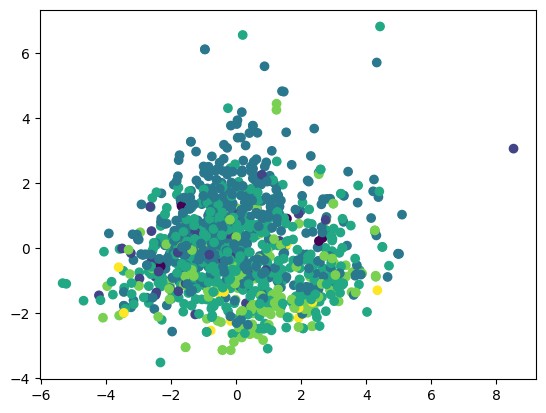

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_train)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_train)
pca.explained_variance_ratio_

In [19]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(SVC(), {
    'C': [0.1, 0.5, 1, 5, 10],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
})

grid_search.fit(X_train, y_train)
grid_search.best_score_, grid_search.best_params_

(np.float64(0.6129718137254903), {'C': 10, 'kernel': 'rbf'})

In [ ]:
grid_search = GridSearchCV(XGBClassifier(), {
    'n_estimators': [100, 200],
    'max_depth': [6],
    'learning_rate': [0.01, 0.1, 0.05],
}, verbose=1, cv=5)

grid_search.fit(X_train, y_train)
grid_search.best_score_, grid_search.best_params_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


(np.float64(0.6020128676470587),
 {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200})

In [45]:
from xgboost import XGBRegressor
grid_search = GridSearchCV(XGBRegressor(), {
    'n_estimators': [100, 200],
    'max_depth': [6],
    'learning_rate': [0.01, 0.1, 0.05],
}, verbose=2, cv=5)

grid_search.fit(X_train, model_y_train)
preds = grid_search.best_estimator_.predict(X_test_small)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=200; total time=   0.5s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=200; total time=   0.5s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=200; total time=   0.5s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=200; total time=   0.5s
[CV] END ..learning_rate=0.01, max_depth=6, n_estimators=200; total time=   0.5s
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=100; total time=   0.2s
[CV] END ...learning_rate=0.1, max_depth=6, n_est

In [46]:
accuracy_score(y_test_small, preds.argmax(axis=1))

0.66

In [48]:
grid_search = GridSearchCV(SGDClassifier(), {
    'penalty': ['l1', 'l2'],
    'alpha': [1e-3, 1e-4, 1e-5],
    'max_iter': [100, 500, 1000, 2000]
})

grid_search.fit(X_train, y_train)
grid_search.best_score_, grid_search.best_params_

(np.float64(0.5535202205882352),
 {'alpha': 0.0001, 'max_iter': 100, 'penalty': 'l1'})

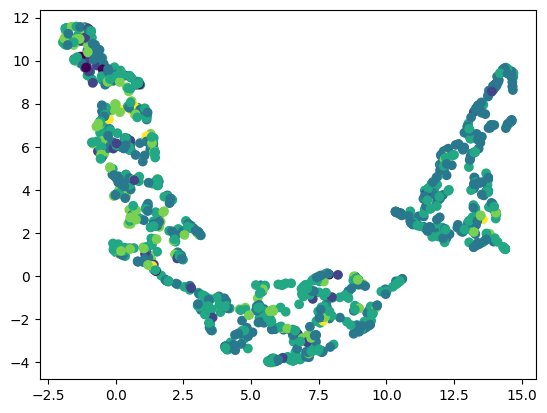

In [49]:
from umap import UMAP
u_map = UMAP(n_components=2)
x_umap = u_map.fit_transform(X_train)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=y_train)

In [68]:
model = torch.jit.load('./data_classification3/secret_model.pt')
X_train, X_test_small, y_train, y_test_small = torch.load("./data_classification3/data.pt")

def generate_random_data(X_train, num_samples=1000):
    feature_num = X_train.size(1)

    random_data = torch.zeros(num_samples, feature_num)
    for i in range(feature_num):
        data = X_train[:, i]
        min_val = data.min().item()
        max_val = data.max().item()

        random_data[:, i] = min_val + (max_val - min_val) * torch.rand(num_samples)

    return random_data

random_data = generate_random_data(X_train, num_samples=10000)
     
synthetic_x_train = torch.cat((X_train, random_data))
synthetic_x_train.shape

torch.Size([11279, 11])

In [69]:
with torch.no_grad():
    model.eval()

    nn_train_preds = model(synthetic_x_train)

    _, nn_train_labels = torch.max(nn_train_preds, 1)

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create and train the Random Forest classifier
grid_search = GridSearchCV(RandomForestClassifier(), param_grid={
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 10, None],
    # 'min_samples_split': [4],
})

grid_search.fit(X_train, y_train)
forest_test_labels = grid_search.best_estimator_.predict(X_test_small)
accuracy_score(y_test_small, forest_test_labels)

0.76

In [63]:
grid_search.best_params_

{'max_depth': None, 'n_estimators': 500}

In [70]:
rand_forest = RandomForestClassifier(n_estimators=500, max_depth=None)
rand_forest.fit(synthetic_x_train, nn_train_labels)
preds = rand_forest.predict(X_test_small)
accuracy_score(y_test_small, preds)

0.77